# Spell-level survival — Cox & AFT

The persistence notebook modelled survival *block by block* (duration-so-far is a valid regressor).
Cox and AFT take the **spell** as the unit and model its whole length, so here **duration is the
outcome / time axis, never a regressor** — feeding `spell_duration` back in would be circular.

## The dataframe these models need — one row per spell

| column | role | measured at |
|---|---|---|
| `duration` | **time axis** (outcome) | spell length in blocks |
| `event` | censoring flag | `1` = closure observed, `0` = right-censored |
| `log_base_fee`, `gas_util`, `tip_p90`, `mev_intensity`, `freq`, `dlogL` | baseline covariates | **`onset_block − 1`** (block *before* onset) |
| `log_vol` | baseline covariate | **`onset_block`** (already backward-looking) |
| ~~`spell_duration`~~ | — | **excluded** (it *is* the outcome) |

The trading-shaped covariates are taken at **onset − 1** (predetermined, the spell-level analogue of
the block `_lag`); `log_vol` at onset since `ewma_vol` is already backward-looking. Built from the
full panel (the closure set excludes every spell's own onset block); left-truncated spells are
dropped. All logic lives in `arblib.estimation`.

In [1]:
%matplotlib inline
import warnings
warnings.filterwarnings("ignore")
import pandas as pd
import matplotlib.pyplot as plt
from lifelines import CoxPHFitter, WeibullAFTFitter

from arblib import estimation as est
from arblib.config import STUDY as S

panel = est.load_panel(S)
print("panel:", panel.shape)

panel: (4725, 28)


## Spell-level survival sample

`build_survival_sample` anchors each baseline covariate at the block described above; `spell_duration`
is not carried.

In [2]:
surv = est.build_survival_sample(panel, quantile=0.2)
surv.head()

spells: 116 | closed: 116 | censored: 0 | left-truncated: 3 | median duration: 1.0
survival: 111 spells from 116 | events: 111 | pairs: 11 | dropped 3 left-truncated | dropped 2 with undefined pre-onset covariate


,spell_id,pair,onset_block,duration,event,log_base_fee,gas_util,tip_p90,mev_intensity,freq,log_vol,dlogL,left_truncated
0,pancake_1_vs_pancake_2_q20_3,pancake_1_vs_pancake_2,24133472,1,1,18.816602,0.477841,20.631389,21.441512,0.372732,-6.919863,0.000000,False
1,pancake_1_vs_pancake_2_q20_5,pancake_1_vs_pancake_2,24133544,3,1,18.761656,0.212214,20.836595,21.380426,0.453182,-7.000378,0.000000,False
2,pancake_1_vs_pancake_2_q20_7,pancake_1_vs_pancake_2,24133553,2,1,18.605701,0.069812,21.416413,20.824011,0.430212,-7.013625,0.000000,False
3,pancake_1_vs_pancake_2_q20_9,pancake_1_vs_pancake_2,24133556,1,1,18.590868,0.507158,21.416413,20.946194,0.563664,-7.013625,-0.000057,False
4,pancake_1_vs_pancake_2_q20_11,pancake_1_vs_pancake_2,24133619,2,1,18.542212,0.501916,21.416413,19.559365,0.291018,-7.082639,0.000000,False


## Cox proportional-hazards model

Models the closure hazard on the baseline covariates (`exp(coef)` = hazard ratio, `>1` = faster
closure). SEs clustered by pool pair. `duration` enters only as the time axis.

concordance: 0.61


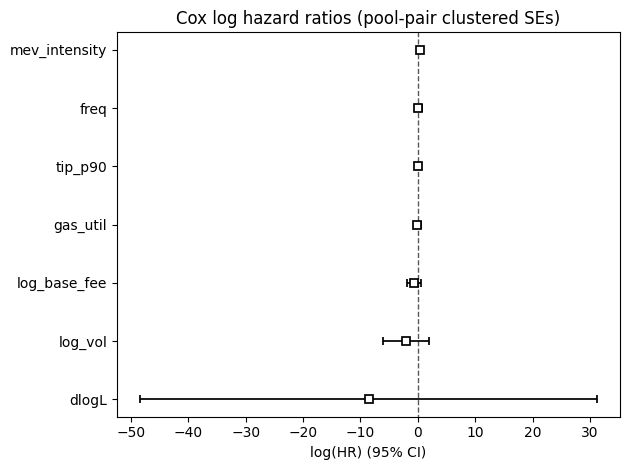

,coef,exp(coef),se(coef),coef lower 95%,coef upper 95%,exp(coef) lower 95%,exp(coef) upper 95%,cmp to,z,p,-log2(p)
covariate,,,,,,,,,,,
log_base_fee,-0.690738,0.501206,0.595079,-1.857071,0.475594,1.561293e-01,1.608970e+00,0.0,-1.160752,0.245743,2.024779
gas_util,-0.087750,0.915990,0.314140,-0.703454,0.527954,4.948732e-01,1.695460e+00,0.0,-0.279333,0.779990,0.358473
tip_p90,0.049008,1.050229,0.013416,0.022714,0.075302,1.022974e+00,1.078210e+00,0.0,3.653075,0.000259,11.914102
mev_intensity,0.306453,1.358597,0.185744,-0.057598,0.670503,9.440294e-01,1.955221e+00,0.0,1.649870,0.098970,3.336871
freq,0.063476,1.065534,0.316953,-0.557741,0.684693,5.725010e-01,1.983163e+00,0.0,0.200270,0.841270,0.249360
log_vol,-2.062737,0.127106,2.020226,-6.022307,1.896833,2.424070e-03,6.664756e+00,0.0,-1.021043,0.307234,1.702589
dlogL,-8.592558,0.000185,20.330640,-48.439880,31.254765,9.179679e-22,3.747760e+13,0.0,-0.422641,0.672557,0.572271


In [3]:
cox = CoxPHFitter()
cox.fit(surv[["duration", "event", "pair"] + est.SURVIVAL_TERMS],
        duration_col="duration", event_col="event", cluster_col="pair", robust=True)

print("concordance:", round(cox.concordance_index_, 3))
cox.plot(); plt.title("Cox log hazard ratios (pool-pair clustered SEs)"); plt.tight_layout(); plt.show()
cox.summary

## Weibull AFT model

The accelerated-failure-time complement: models log survival time directly, so `exp(coef)` on the
`lambda_` params is a *time* ratio (`>1` = longer spells). A robustness on the proportional-hazards
assumption.

In [4]:
aft = WeibullAFTFitter()
aft.fit(surv[["duration", "event"] + est.SURVIVAL_TERMS], duration_col="duration", event_col="event")

print("median survival (blocks):", round(aft.median_survival_time_, 2),
      "| concordance:", round(aft.concordance_index_, 3))
aft.summary

median survival (blocks): 1.85 | concordance: 0.6


coef   exp(coef)   se(coef)  coef lower 95%  \
param   covariate                                                        
lambda_ dlogL          0.506280    1.659107  17.044863      -32.901038   
        freq          -0.080726    0.922447   0.173333       -0.420453   
        gas_util       0.140752    1.151139   0.304015       -0.455106   
        log_base_fee   0.781842    2.185494   0.651829       -0.495719   
        log_vol        1.857024    6.404647   1.046996       -0.195051   
        mev_intensity -0.268203    0.764752   0.109029       -0.481895   
        tip_p90       -0.037454    0.963239   0.031326       -0.098852   
        Intercept      5.516825  248.843760  16.862296      -27.532667   
rho_    Intercept      0.467649    1.596237   0.070418        0.329631   

                       coef upper 95%  exp(coef) lower 95%  \
param   covariate                                            
lambda_ dlogL               33.913597         5.143525e-15   
        freq                 0.259001         6.567495e-01   
        gas_util             0.736609         6.343807e-01   
        log_base_fee         2.059403         6.091327e-01   
        log_vol              3.909099         8.227923e-01   
        mev_intensity       -0.054511         6.176118e-01   
        tip_p90              0.023944         9.058771e-01   
        Intercept           38.566318         1.103353e-12   
rho_    Intercept            0.605666         1.390455e+00   

                       exp(coef) upper 95%  cmp to         z             p  \
param   covariate                                                            
lambda_ dlogL                 5.351653e+14     0.0  0.029703  9.763041e-01   
        freq                  1.295635e+00     0.0 -0.465726  6.414118e-01   
        gas_util              2.088841e+00     0.0  0.462976  6.433813e-01   
        log_base_fee          7.841289e+00     0.0  1.199459  2.303495e-01   
        log_vol               4.985403e+01     0.0  1.773668  7.611812e-02   
        mev_intensity         9.469479e-01     0.0 -2.459936  1.389619e-02   
        tip_p90               1.024233e+00     0.0 -1.195613  2.318475e-01   
        Intercept             5.612277e+16     0.0  0.327169  7.435399e-01   
rho_    Intercept             1.832472e+00     0.0  6.641011  3.115378e-11   

                        -log2(p)  
param   covariate                 
lambda_ dlogL           0.034597  
        freq            0.640677  
        gas_util        0.636254  
        log_base_fee    2.118104  
        log_vol         3.715616  
        mev_intensity   6.169167  
        tip_p90         2.108752  
        Intercept       0.427518  
rho_    Intercept      34.901802